# BERTweet Fine-tuning
Fine-tunes `vinai/bertweet-base` for stance detection.

Run twice: once with `DATASET = 'cvs'`, once with `DATASET = 'te'`.


**Note**: All the results will be saved and read on/from the local Google Drive in `StanceProject` directory.

In [ ]:
!pip install -q transformers accelerate scikit-learn pandas datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/StanceProject'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project: /content/drive/MyDrive/StanceProject


In [ ]:
# load all libraries
import pandas as pd
import numpy as np
import re, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Choose dataset

Change this value and re-run all cells below to train on the other dataset.

In [ ]:
DATASET = 'cvs'
# 'cvs' = covid-vax-stance
# 'te' = TweetEval stance_abortion

cvs = pd.read_csv(f'{PROJECT}/data/processed/covid_vax_stance.csv')
te = pd.read_csv(f'{PROJECT}/data/processed/tweeteval_stance.csv')

df = cvs.copy() if DATASET == 'cvs' else te.copy()
dataset_name = 'covid-vax-stance' if DATASET == 'cvs' else 'TweetEval-stance'
print(f'Dataset: {dataset_name} ({len(df)} rows)')

Dataset: covid-vax-stance  (3139 rows)


## Preprocessing & label encoding

In [ ]:
def preprocess_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+', 'HTTPURL', text)
    text = re.sub(r'@\w+', '@USER', text)
    return text.strip()

df['clean'] = df['text'].apply(preprocess_tweet)

label_names = sorted(df['label'].dropna().unique().tolist())
label2id = {l: i for i, l in enumerate(label_names)}
id2label = {i: l for l, i in label2id.items()}

df['label_id'] = df['label'].map(label2id)
df = df.dropna(subset=['label_id']).copy()
df['label_id'] = df['label_id'].astype(int)

print(f'Labels: {label2id}')

Labels: {'AntiVax': 0, 'Neutral': 1, 'ProVax': 2}


## Train / val / test split

In [ ]:
if 'split' in df.columns and df['split'].nunique() > 1:
    train_df = df[df['split'] == 'train'].copy()
    test_df = df[df['split'].isin(['test','validation'])].copy()
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label_id'])
else:
    train_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['label_id'])
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label_id'])

print(f'Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}')

Train=2401  Val=267  Test=471


## Tokenise

In [ ]:
MODEL_NAME = 'vinai/bertweet-base'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len=128):
        self.enc = tok(list(texts), truncation=True, padding=True, max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]
        return item

train_ds = TweetDataset(train_df['clean'], train_df['label_id'], tokenizer)
val_ds = TweetDataset(val_df['clean'],   val_df['label_id'],   tokenizer)
test_ds = TweetDataset(test_df['clean'],  test_df['label_id'],  tokenizer)
print(f'Datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Datasets: train=2401 val=267 test=471


## Train

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

# compute class weights to counter imbalance
cw = compute_class_weight('balanced', classes=np.arange(len(label_names)), y=train_df['label_id'].values)
class_weights = torch.tensor(cw, dtype=torch.float).to(device)
print('Class weights:', {id2label[i]: round(w, 3) for i, w in enumerate(cw)})

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names), id2label=id2label, label2id=label2id
).to(device)

def compute_metrics(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return {'macro_f1': f1_score(ep.label_ids, preds, average='macro')}

total_steps = (len(train_ds) // 32 + 1) * 10
warmup_steps = int(total_steps * 0.1)
ckpt_dir = f'{PROJECT}/models/bertweet_{DATASET}'

trainer = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir=ckpt_dir,
        num_train_epochs=10,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_steps=warmup_steps,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        logging_steps=20,
        report_to='none',
        fp16=torch.cuda.is_available(),
    ),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)
trainer.train()

import json
log_path = f'{PROJECT}/results/bertweet_{DATASET}_training_log.json'
with open(log_path, 'w') as f:
    json.dump(trainer.state.log_history, f)

Class weights: {'AntiVax': np.float64(2.134), 'Neutral': np.float64(0.814), 'ProVax': np.float64(0.767)}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.086366,1.042423,0.427399
2,0.910672,0.889910,0.469149
3,0.720697,0.959878,0.564633
4,0.542720,0.987879,0.553836
5,0.360613,1.238909,0.515840
6,0.297289,1.236629,0.530342
7,0.194038,1.410557,0.519904
8,0.145760,1.529095,0.521079
9,0.095496,1.595940,0.516084
10,0.083085,1.624593,0.518113


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training log saved: /content/drive/MyDrive/StanceProject/results/bertweet_cvs_training_log.json
Best checkpoint saved to Drive: /content/drive/MyDrive/StanceProject/models/bertweet_cvs


## Evaluate & save predictions

=== BERTweet on covid-vax-stance ===
              precision    recall  f1-score   support

     AntiVax      0.632     0.493     0.554        73
     Neutral      0.704     0.518     0.597       193
      ProVax      0.632     0.839     0.721       205

    accuracy                          0.654       471
   macro avg      0.656     0.617     0.624       471
weighted avg      0.662     0.654     0.644       471



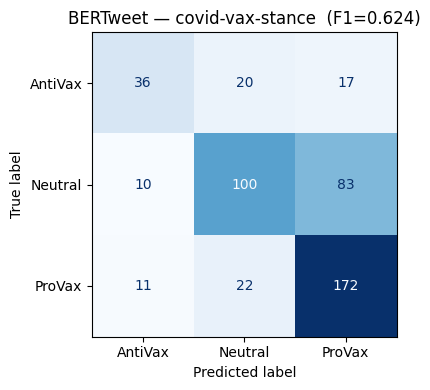

Predictions saved to Drive: /content/drive/MyDrive/StanceProject/predictions/bertweet_cvs_preds.csv
Macro-F1: 0.6240  |  Accuracy: 0.654


In [ ]:
preds_out = trainer.predict(test_ds)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = test_df['label_id'].values
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

# confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=label_names).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'BERTweet - {dataset_name}  (F1={macro_f1:.3f})')
plt.tight_layout()
plt.savefig(f'{PROJECT}/plots/cm_bertweet_{DATASET}.png', bbox_inches='tight')
plt.show()

# predictions CSV
out = test_df.copy()
out['pred_id'] = y_pred
out['pred_label'] = [id2label[i] for i in y_pred]
out['correct'] = (out['label_id'] == out['pred_id'])
preds_path = f'{PROJECT}/predictions/bertweet_{DATASET}_preds.csv'
out.to_csv(preds_path, index=False)